# Neural Networks Model

In [411]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import random
import numpy as np

import copy

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix

import matplotlib.pylab as plt
%matplotlib inline

from data_cleaning import cleaned_data

random.seed(1234)
np.random.seed(1234)
torch.manual_seed(1234)

In [412]:
class Dataset:
    """
    Prepare the dataset into training, validation, and test sets.
    """
    def __init__(self, random_state = 123):
        self.data = cleaned_data()
        y_df = self.data["VOTED"].map({"voted": 1, "not_voted": 0}).to_numpy()

        categorical_feature = ["SEX", "RACE", "EDUC", "EMPSTAT", "NATIVITY", "REGION",
                               "METRO", "MARST", "DIFFMOB"]
        numerical_feature = ["AGE", "FAMSIZE", "NCHILD", "FAMINC", "INCOME_PER_PERSON"]

        ## training set 70%, validation set 10%, test set 20%
        train_x, rest_x, self.train_y, rest_y = train_test_split(
            self.data, y_df, test_size=0.3, random_state=random_state)
        val_x, test_x, self.val_y, self.test_y = train_test_split(
            rest_x, rest_y, test_size=(2/3), random_state=random_state)
        
        self.ohe = OneHotEncoder(sparse_output=False)
        self.scaler = StandardScaler()

        train_x_categorical = self.ohe.fit_transform(train_x[categorical_feature])
        train_x_numerical = self.scaler.fit_transform(train_x[numerical_feature])
        val_x_categorical = self.ohe.transform(val_x[categorical_feature])
        val_x_numerical = self.scaler.transform(val_x[numerical_feature])
        test_x_categorical = self.ohe.transform(test_x[categorical_feature])
        test_x_numerical = self.scaler.transform(test_x[numerical_feature])

        self.train_x = np.concatenate([train_x_categorical, train_x_numerical], axis=1)
        self.val_x = np.concatenate([val_x_categorical, val_x_numerical], axis=1)
        self.test_x = np.concatenate([test_x_categorical, test_x_numerical], axis=1)

        categorical_feature_name = self.ohe.get_feature_names_out(categorical_feature)
        numerical_feature_name = self.scaler.get_feature_names_out(numerical_feature)
        self.feature_order = np.concatenate([categorical_feature_name, numerical_feature_name])

In [413]:
dataset_handler = Dataset(random_state=1234)

print("\n"*2, dataset_handler.train_x.shape, "\n"*2)
print(dataset_handler.feature_order, "\n"*2)
print(dataset_handler.train_x[:3])



 (43628, 31) 


['SEX_female' 'SEX_male' 'RACE_asian' 'RACE_black'
 'RACE_indian_aleut_eskimo' 'RACE_others' 'RACE_white' 'EDUC_college_grad'
 'EDUC_hs_grad' 'EDUC_master_higher' 'EMPSTAT_employed'
 'EMPSTAT_not_in_labor_force' 'EMPSTAT_retired' 'EMPSTAT_unemployed'
 'NATIVITY_foreign_born' 'NATIVITY_native_born' 'REGION_midwest'
 'REGION_northeast' 'REGION_south' 'REGION_west' 'METRO_metropolitan'
 'METRO_not_metropolitan' 'MARST_has_spouse' 'MARST_no_spouse'
 'DIFFMOB_mobility_limitation' 'DIFFMOB_no_mobility_limitation' 'AGE'
 'FAMSIZE' 'NCHILD' 'FAMINC' 'INCOME_PER_PERSON'] 


[[ 1.          0.          0.          0.          0.          0.
   1.          1.          0.          0.          0.          1.
   0.          0.          1.          0.          1.          0.
   0.          0.          1.          0.          0.          1.
   0.          1.         -0.43837777  2.28542562 -0.58485114 -1.53299425
  -1.33195994]
 [ 0.          1.          0.          0.          0.    

In [414]:
class TorchDataset():

    def __init__(self, dataset_handler, batch_size):
        self.X_train = torch.from_numpy(dataset_handler.train_x).float()
        self.y_train = torch.from_numpy(dataset_handler.train_y).float().view(-1, 1)

        self.X_val = torch.from_numpy(dataset_handler.val_x).float()
        self.y_val = torch.from_numpy(dataset_handler.val_y).float().view(-1, 1)

        self.X_test = torch.from_numpy(dataset_handler.test_x).float()
        self.y_test = torch.from_numpy(dataset_handler.test_y).float().view(-1, 1)

        ## Pure SGD takes too long to train the model. Therefore, mini-batch training is introduced.
        self.train_loader = DataLoader(TensorDataset(self.X_train, self.y_train), batch_size=batch_size, shuffle=True)

In [415]:
class TorchNetwork(nn.Module):

    def __init__(self, num_features, hidden_layer, hidden_dim):
        super().__init__()
        layers = []
        ## Input Layer
        layers.append(nn.Linear(num_features, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(hidden_layer-1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, 1))
        self.n = nn.Sequential(*layers)

    def forward(self, x):
        return self.n(x)

class Model():
    
    def __init__(self, dataset, batch_size, hidden_layer, hidden_dim, lr, penalty):
        self.torch_dataset = TorchDataset(dataset, batch_size)
        self.model = TorchNetwork(self.torch_dataset.X_train.shape[1], hidden_layer, hidden_dim)
        self.optim = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=penalty)
        self.pos_weight = torch.tensor([(self.torch_dataset.y_train == 0).sum()/(self.torch_dataset.y_train == 1).sum()]).float()
        self.loss_func = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

    def train(self, epochs=50, threshold=0.5):

        f1_history = []
        initial_loss = None

        for epoch in range(epochs):
            self.model.train()
            total_loss = 0

            for x, y in self.torch_dataset.train_loader:
                self.optim.zero_grad()
            
                output = self.model(x)
                batch_loss = self.loss_func(output, y)

                batch_loss.backward()
                self.optim.step()
                total_loss += batch_loss.item() * x.size(0)

            avg_loss = total_loss/len(self.torch_dataset.X_train)

            if epoch == 0 :
                initial_loss = avg_loss
            elif epoch > 5 and avg_loss > initial_loss:
                return []
    
            self.model.eval()
            with torch.no_grad():
                result = self.model(self.torch_dataset.X_val)
                hat_y = (torch.sigmoid(result) > threshold).float()
                f1 = f1_score(self.torch_dataset.y_val.numpy(), hat_y.numpy())
                f1_history.append(f1)

        return f1_history

    def test(self, threshold=0.5):
        self.model.eval()
        with torch.no_grad():
            result = self.model(self.torch_dataset.X_test)
            hat_y = (torch.sigmoid(result) > threshold).float()
            f1 = f1_score(self.torch_dataset.y_test.numpy(), hat_y.numpy())
            conf_matrix = confusion_matrix(self.torch_dataset.y_test.numpy(), hat_y.numpy())
            tn, fp, fn, tp = conf_matrix[0,0], conf_matrix[0,1], conf_matrix[1,0], conf_matrix[1,1]
        print("F1:", f1, "\n")
        print("False negative rate:", fn / (fn + tp), "\n")
        print("False positive rate:", fp / (fp + tn), "\n")


In [429]:
batch_size = [50, 100, 200]
hidden_layer = [2, 5, 10]
hidden_dim = [31, 62]
learning_rate = [0.01, 0.001, 0.0001]
penalty = [0.01, 0.001, 0.0001]

best_f1_mean = 0
best_hyperparameter = None
best_model = None

for bs in batch_size:
    for hl in hidden_layer:
        for hd in hidden_dim:
            for lr in learning_rate:
                for p in penalty:
                    model = Model(dataset_handler, bs, hl, hd, lr, p)
                    f1_history = model.train(epochs=20)
                    if not f1_history or len(f1_history) < 5:
                        continue
                    f1_std = np.std(f1_history)
                    if f1_std > 0.2 or f1_std < 0.001:
                        continue
                    current_f1_mean = np.mean(f1_history[-5:])
                    print(bs, hl, hd, lr, p, current_f1_mean)
                    if current_f1_mean > best_f1_mean:
                        best_f1_mean = current_f1_mean
                        best_hyperparameter = {"Batch size": bs, "Number of hidden layers": hl,
                                               "Hidden dimension": hd, "Learning rate": lr, "Penalty rate": p}
                        best_model = copy.deepcopy(model.model.state_dict())
                        
print("Best F1:", best_f1_mean)
print("Best Model", best_hyperparameter)

50 2 31 0.01 0.01 0.7662407870405028
50 2 31 0.01 0.001 0.767429172249573
50 2 31 0.01 0.0001 0.7625518843552095
50 2 31 0.001 0.01 0.7738578793178413
50 2 31 0.001 0.001 0.7744306403086743
50 2 31 0.001 0.0001 0.7617185128848745
50 2 31 0.0001 0.01 0.772912838027488
50 2 31 0.0001 0.001 0.7741227888359223
50 2 31 0.0001 0.0001 0.7685664461344628
50 2 62 0.01 0.01 0.7619501100336845
50 2 62 0.01 0.001 0.7581093276910797
50 2 62 0.01 0.0001 0.7643280278753986
50 2 62 0.001 0.01 0.7714988170171503
50 2 62 0.001 0.001 0.7698315176099395
50 2 62 0.001 0.0001 0.7733521170221793
50 2 62 0.0001 0.01 0.7769331085369564
50 2 62 0.0001 0.001 0.7684580888928718
50 2 62 0.0001 0.0001 0.771065204286331
50 5 31 0.01 0.001 0.7840699118345318
50 5 31 0.01 0.0001 0.7753109636631791
50 5 31 0.001 0.001 0.7611259243331527
50 5 31 0.001 0.0001 0.7794383428529484
50 5 31 0.0001 0.001 0.7755689961510372
50 5 31 0.0001 0.0001 0.7703536033599465
50 5 62 0.01 0.0001 0.7785053077124047
50 5 62 0.001 0.001 0.773

In [433]:
final_model = Model(dataset_handler, 100, 5, 62, 0.001, 0.0001)
final_model.train()

[0.8006802721088435,
 0.789249048333141,
 0.7607391408687305,
 0.7897753324163228,
 0.7648671195328328,
 0.7590173756740564,
 0.7920633100126161,
 0.7509095318942518,
 0.7603166986564299,
 0.800858466056704,
 0.7851182197496523,
 0.7826592282659228,
 0.7870788468218132,
 0.7697041420118343,
 0.7903021946455245,
 0.7512395694763575,
 0.7377069282648682,
 0.7335307179866766,
 0.7700673838515191,
 0.7874015748031497,
 0.760229720028715,
 0.7925653969710876,
 0.7849924497618771,
 0.7920860018298261,
 0.7885635231727001,
 0.7476092482750273,
 0.7768536956776385,
 0.7648106375400688,
 0.7825378346915017,
 0.7585546781526681,
 0.772041489863272,
 0.7916283348666053,
 0.7975837702302256,
 0.7769699812382739,
 0.7758115551388726,
 0.7996822154125525,
 0.79854561981593,
 0.798131692868535,
 0.7973693162490079,
 0.7730104619724932,
 0.77594862813777,
 0.7832038046630321,
 0.7895222709439188,
 0.7871116225546605,
 0.7823576954162337,
 0.7907137110676934,
 0.7758782201405152,
 0.7667098903689732,
 

In [436]:
final_model.test()

F1: 0.7672297098463893 

False negative rate: 0.3179868159464267 

False positive rate: 0.31488484015125473 



In [439]:
final_test_model = Model(dataset_handler, best_hyperparameter["Batch size"],
                         best_hyperparameter["Number of hidden layers"],
                         best_hyperparameter["Hidden dimension"],
                         best_hyperparameter["Learning rate"],
                         best_hyperparameter["Penalty rate"])

final_test_model.model.load_state_dict(best_model)
final_test_model.test()

F1: 0.7738540692235735 

False negative rate: 0.3075232813644449 

False positive rate: 0.31935372980405635 



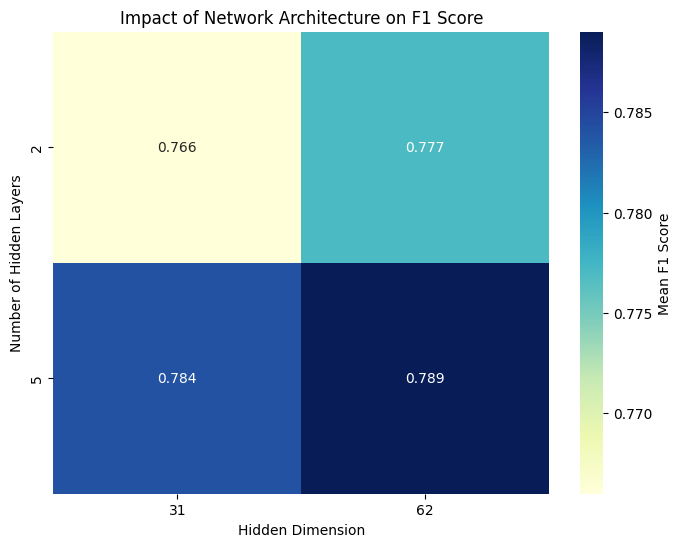

In [440]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 텍스트로 된 결과를 리스트로 변환 (직접 입력 혹은 복사)
# 리스트 형식: [Batch, Layer, Dim, LR, Penalty, F1]
raw_data = [
    [50, 2, 31, 0.01, 0.01, 0.766], [50, 5, 31, 0.01, 0.001, 0.784],
    [100, 5, 62, 0.001, 0.0001, 0.789], [200, 2, 62, 0.0001, 0.001, 0.777],
    # ... (가지고 계신 전체 데이터를 여기에 넣으세요)
]

columns = ['Batch_size', 'Hidden_layer', 'Hidden_dim', 'LR', 'Penalty', 'F1']
df = pd.DataFrame(raw_data, columns=columns)

# 2. 히트맵을 위해 특정 변수 고정 (예: 가장 성적이 좋았던 LR=0.001, Penalty=0.0001 조건만 추출)
# 혹은 전체 데이터의 평균 성능을 보고 싶다면 groupby를 사용합니다.
pivot_table = df.groupby(['Hidden_layer', 'Hidden_dim'])['F1'].mean().unstack()

# 3. 히트맵 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".3f", cbar_kws={'label': 'Mean F1 Score'})
plt.title('Impact of Network Architecture on F1 Score')
plt.xlabel('Hidden Dimension')
plt.ylabel('Number of Hidden Layers')
plt.show()
